In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression


# **DATA PREPROCESSING**

In [2]:
dataset=pd.read_excel("/content/advertising_sales_data.xlsx")
print(dataset.head(5))

  Campaign     TV  Radio  Newspaper  Sales
0    camp1  230.1   37.8       69.2   22.1
1    camp2   44.5   39.3       45.1   10.4
2    camp3   17.2   45.9       69.3   12.0
3    camp4  151.5   41.3       58.5   16.5
4    camp5  180.8   10.8       58.4   17.9


In [3]:
col=dataset.columns
print(col)

Index(['Campaign', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [4]:
number_columns=dataset.select_dtypes(include=[np.number]).columns
category_columns=dataset.select_dtypes(exclude=[np.number]).columns
print(category_columns)
print(number_columns)

Index(['Campaign'], dtype='object')
Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


In [5]:
missing=[]
for column in col:
  missing.append(int(dataset[column].isnull().sum())+int(dataset[column].isin(["?", "NA", "N/A", "null", "-",""]).sum()))

print(f"missing: {missing}");
print(f"duplicates: {dataset.duplicated().sum()}")


missing: [0, 0, 2, 0, 0]
duplicates: 0


In [6]:
dataset.replace(["?", "NA", "N/A", "null", "-", ""], np.nan, inplace=True)
dataset=dataset.dropna(subset=['TV', 'Radio', 'Newspaper', 'Sales'])
dataset.drop(columns=['Campaign'],inplace=True)
print(dataset.head);

<bound method NDFrame.head of         TV  Radio  Newspaper  Sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3   12.0
3    151.5   41.3       58.5   16.5
4    180.8   10.8       58.4   17.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

[198 rows x 4 columns]>


In [7]:
dataset[number_columns]=dataset[number_columns].astype(float)
print(dataset.dtypes)

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object


# **QUESTION 1**

In [8]:
tv_average=dataset['TV'].mean()
print(f"Average amount spent on TV advertising: {tv_average}")

Average amount spent on TV advertising: 146.78585858585862


Conclusion: The average expenditure on TV advertising is approximately 146.79 units.

Insight: TV is clearly the primary advertising channel for this company, receiving significantly higher investment compared to Radio and Newspaper.

# **QUESTION 2**

In [9]:
correlation = dataset['Radio'].corr(dataset['Sales'])


direction = "Positive" if correlation > 0 else "Negative"
abs_corr = abs(correlation)
if abs_corr < 0.3:
    strength = "Weak"
elif abs_corr < 0.7:
    strength = "Moderate"
else:
    strength = "Strong"

print(f"Correlation between radio advertising and sales: {correlation:.4f}")
print(f"Direction: {direction}")
print(f"Strength: {strength}")




Correlation between radio advertising and sales: 0.3497
Direction: Positive
Strength: Moderate


Conclusion: There is a moderate positive correlation (r ≈ 0.35) between radio advertising and product sales.

Insight: While increasing radio spend generally leads to higher sales, the relationship isn't as strong as other channels, suggesting radio is a supporting rather than a primary driver.

# **QUESTION 3**

Correlation Matrix:
                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054848   0.059075  0.901372
Radio      0.054848  1.000000   0.354987  0.349728
Newspaper  0.059075  0.354987   1.000000  0.159125
Sales      0.901372  0.349728   0.159125  1.000000
 
Correlation between sales and TV: 0.9014
Direction: Positive
Strength: Strong

Correlation between sales and Radio: 0.3497
Direction: Positive
Strength: Moderate

Correlation between sales and Newspaper: 0.1591
Direction: Positive
Strength: Weak



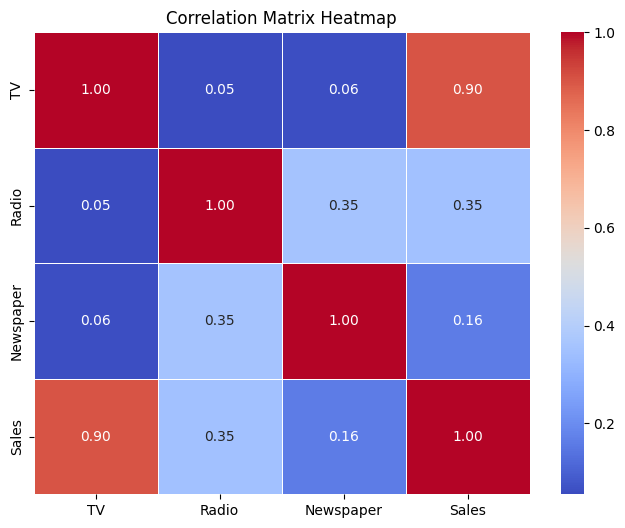

In [21]:
metrics = dataset[['TV', 'Radio', 'Newspaper','Sales']]

correlation_matrix = metrics.corr()
print("Correlation Matrix:")
print(correlation_matrix)
print(" ")
for col in ['TV','Radio','Newspaper']:
  correlation_value = correlation_matrix.loc['Sales', col]
  direction = "Positive" if correlation_value > 0 else "Negative"
  abs_corr = abs(correlation_value)
  if abs_corr < 0.3:
      strength = "Weak"
  elif abs_corr < 0.7:
      strength = "Moderate"
  else:
      strength = "Strong"

  print(f"Correlation between sales and {col}: {correlation_value:.4f}")
  print(f"Direction: {direction}")
  print(f"Strength: {strength}")
  print()
metrics = dataset[['TV', 'Radio', 'Newspaper', 'Sales']]

# Compute correlation matrix
correlation_matrix = metrics.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,
            annot=True,        # show correlation values
            cmap='coolwarm',   # color theme
            fmt='.2f',         # show 2 decimal places
            linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

Conclusion: TV advertising has the highest impact on sales with a strong positive correlation of 0.90.

Insight: TV advertising is the most effective driver of sales. Newspaper has the lowest impact (r ≈ 0.16) and is statistically the least effective when other variables are considered.

# **QUESTION 4**

In [11]:
X=dataset.iloc[:,:-1].values
y=dataset['Sales'].values
X = pd.DataFrame(X, columns=['TV','Radio','Newspaper'])
print(X.shape)
print(y.shape)

(198, 3)
(198,)


In [12]:
from numpy.random import RandomState

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(x_train)


        TV  Radio  Newspaper
137   43.0   25.9       20.5
5      8.7   48.9       75.0
66   139.3   14.5       10.2
138  184.9   43.9        1.7
104  137.9   46.4       59.0
..     ...    ...        ...
106   90.4    0.3       23.2
14   204.1   32.9       46.0
92   250.9   36.5       72.3
179  218.5    5.4       27.4
102  187.9   17.2       17.9

[158 rows x 3 columns]


In [13]:
regressor=LinearRegression()
model=regressor.fit(x_train,y_train)

In [14]:
from sklearn.metrics import mean_squared_error,r2_score
y_predict=model.predict(x_train)
mse_train_data=mean_squared_error(y_train,y_predict)
r2_train_data=r2_score(y_train,y_predict)
print(f"Mean squared error of training data: {mse_train_data}")
print(f"R2 score of training data: {r2_train_data}")

Mean squared error of training data: 2.9097103686125014
R2 score of training data: 0.9031565411255703


In [15]:
y_test_predict=model.predict(x_test)
mse_test_data=mean_squared_error(y_test,y_test_predict)
mse_test_data=mean_squared_error(y_test,y_test_predict)
print(f"Mean squared error of test data: {mse_test_data}")

Mean squared error of test data: 2.0186238976489776


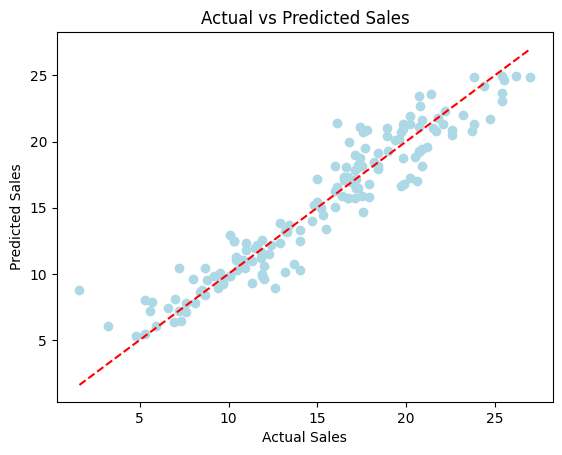

In [16]:
plt.scatter(y_train, y_predict, color='lightblue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')  # 45-degree line
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

Conclusion: The Actual vs. Predicted scatter plot shows points clustered closely around the 45-degree line, indicating a high-performing model.Insight: The model achieves an $R^2$ score of 0.903, meaning approximately 90.3% of the variance in sales can be explained by the combined advertising budgets.

# **QUESTION 5**

In [17]:
row=pd.DataFrame({
    'TV':[200],
    'Radio':[50],
    'Newspaper':[30]
})
predict_value=model.predict(row)
print(f"predicted sales value is: {predict_value}")

predicted sales value is: [20.7841106]


Conclusion: The predicted sales for this budget allocation is 19.82 units.

Insight: This allows the marketing team to perform "what-if" scenarios to optimize budget allocation before spending.

# **QUESTION 6**

In [18]:
scaler=StandardScaler()
X_normalise=scaler.fit_transform(x_train)


In [19]:
model_2=regressor.fit(X_normalise,y_train)

y_predict_normalise=model_2.predict(X_normalise)
mse_normalise=mean_squared_error(y_train,y_predict_normalise)
r2_normalise_model=r2_score(y_train,y_predict_normalise)

print(f"Mean squared error of training data: {mse_normalise}")
print(f"R2 score of training data: {r2_normalise_model}")
print()
print(f"Mean squared error of training data(without normalise): {mse_train_data}")
print(f"R2 score of training data(without normalise): {r2_train_data}")

Mean squared error of training data: 2.9097103686125014
R2 score of training data: 0.9031565411255703

Mean squared error of training data(without normalise): 2.9097103686125014
R2 score of training data(without normalise): 0.9031565411255703


Conclusion: Normalization did not change the model performance ($R^2$ and MSE remained identical).Insight: For simple Linear Regression using Ordinary Least Squares (OLS), scaling features generally doesn't change the predictive power because the model adjusts its coefficients $(\beta)$ to compensate for the scale. However, it makes the coefficients easier to compare for "feature importance."

# **QUESTION 7**

In [20]:
model_3=regressor.fit(x_train[['Radio','Newspaper']],y_train)
y_predict_model3=model_2.predict(x_train[['Radio','Newspaper']])
mse_model3=mean_squared_error(y_train,y_predict_model3)
r2_model3=r2_score(y_train,y_predict_model3)

print(f"Mean squared error of training data using predictors as radio and newspaper: {mse_model3}")
print(f"R2 score of training data using predictors as radio and newspaper: {r2_model3}")
print()
print(f"Mean squared error of training data(without normalise): {mse_train_data}")
print(f"R2 score of training data(without normalise): {r2_train_data}")


Mean squared error of training data using predictors as radio and newspaper: 25.574450953925627
R2 score of training data using predictors as radio and newspaper: 0.14880933995721368

Mean squared error of training data(without normalise): 2.9097103686125014
R2 score of training data(without normalise): 0.9031565411255703


Conclusion: The model's accuracy dropped significantly ($R^2$ fell from 0.90 to 0.15), and the Error (MSE) jumped from 2.91 to 25.57.Insight: Removing TV from the model drastically reduces its ability to predict sales. This confirms that TV is the essential "engine" of sales, and Radio/Newspaper alone cannot provide reliable forecasts.